# Error Analysis — BERT Amazon Polarity

This notebook analyses the misclassifications made by `atharvadhumal/bert-amazon-polarity` on the Amazon Polarity test set.

**Model:** `bert-base-uncased` fine-tuned for 3 epochs  
**Final F1:** 97.06% on 400,000 test samples

In [1]:
import os
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from sklearn.metrics import confusion_matrix, classification_report
from torch.utils.data import DataLoader
from tqdm.auto import tqdm

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")

Device: cuda


## 1. Load Model & Test Data

In [2]:
MODEL_ID = "atharvadhumal/bert-amazon-polarity"
SAMPLE_SIZE = 5000  # subset for analysis (set to None for full 400k)

tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)
model = AutoModelForSequenceClassification.from_pretrained(MODEL_ID).to(device)
model.eval()
print("Model loaded.")

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Model loaded.


In [3]:
dataset = load_dataset("amazon_polarity", split="test")
if SAMPLE_SIZE:
    dataset = dataset.shuffle(seed=42).select(range(SAMPLE_SIZE))
print(f"Test samples: {len(dataset)}")

Test samples: 5000


## 2. Run Inference

In [4]:
def run_inference(dataset, tokenizer, model, device, batch_size=64):
    all_preds, all_probs, all_labels = [], [], []
    texts = dataset["content"]
    labels = dataset["label"]

    for i in tqdm(range(0, len(texts), batch_size)):
        batch_texts = texts[i : i + batch_size]
        batch_labels = labels[i : i + batch_size]
        inputs = tokenizer(batch_texts, padding=True, truncation=True, max_length=512, return_tensors="pt")
        inputs = {k: v.to(device) for k, v in inputs.items()}
        with torch.no_grad():
            logits = model(**inputs).logits
        probs = torch.softmax(logits, dim=-1).cpu().numpy()
        preds = probs.argmax(axis=-1)
        all_preds.extend(preds)
        all_probs.extend(probs)
        all_labels.extend(batch_labels)

    return np.array(all_preds), np.array(all_probs), np.array(all_labels)

preds, probs, labels = run_inference(dataset, tokenizer, model, device)
print("Inference complete.")

  0%|          | 0/79 [00:00<?, ?it/s]

Inference complete.


## 3. Overall Metrics

              precision    recall  f1-score   support

    Negative       0.96      0.96      0.96      2453
    Positive       0.96      0.96      0.96      2547

    accuracy                           0.96      5000
   macro avg       0.96      0.96      0.96      5000
weighted avg       0.96      0.96      0.96      5000



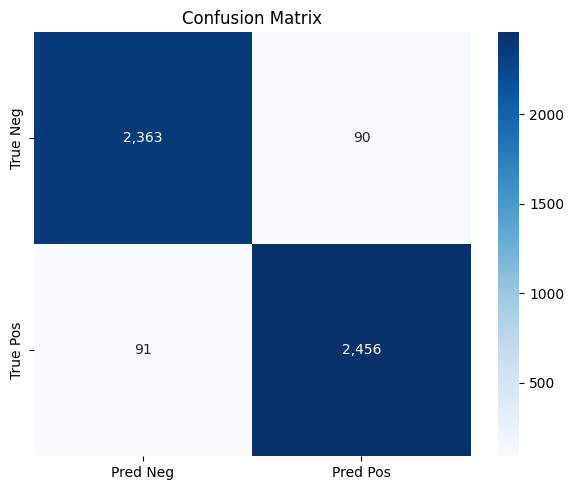

In [5]:
print(classification_report(labels, preds, target_names=["Negative", "Positive"]))

cm = confusion_matrix(labels, preds)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt=",d", cmap="Blues",
            xticklabels=["Pred Neg", "Pred Pos"],
            yticklabels=["True Neg", "True Pos"])
ax.set_title("Confusion Matrix")
plt.tight_layout()
plt.show()

## 4. Error Analysis

In [6]:
df = pd.DataFrame({
    "title": dataset["title"],
    "text": dataset["content"],
    "true_label": labels,
    "pred_label": preds,
    "confidence": probs.max(axis=1),
    "text_length": [len(t.split()) for t in dataset["content"]],
})
df["correct"] = df["true_label"] == df["pred_label"]
df["error_type"] = None
df.loc[(df["true_label"] == 1) & (df["pred_label"] == 0), "error_type"] = "False Negative"
df.loc[(df["true_label"] == 0) & (df["pred_label"] == 1), "error_type"] = "False Positive"

errors = df[~df["correct"]]
print(f"Total errors: {len(errors)} / {len(df)} ({len(errors)/len(df)*100:.2f}%)")
print(f"False Negatives: {(errors['error_type'] == 'False Negative').sum()}")
print(f"False Positives: {(errors['error_type'] == 'False Positive').sum()}")

Total errors: 181 / 5000 (3.62%)
False Negatives: 91
False Positives: 90


### 4a. Confidence Distribution — Errors vs Correct

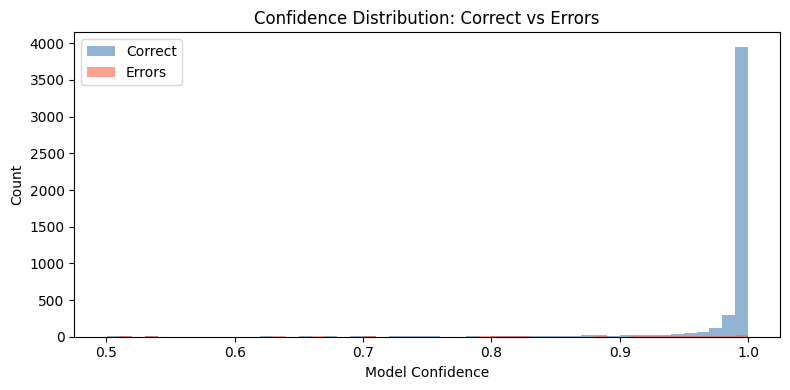

Avg confidence on correct: 0.9834
Avg confidence on errors:  0.8366


In [7]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(df[df["correct"]]["confidence"], bins=50, alpha=0.6, label="Correct", color="steelblue")
ax.hist(errors["confidence"], bins=50, alpha=0.6, label="Errors", color="tomato")
ax.set_xlabel("Model Confidence")
ax.set_ylabel("Count")
ax.set_title("Confidence Distribution: Correct vs Errors")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Avg confidence on correct: {df[df['correct']]['confidence'].mean():.4f}")
print(f"Avg confidence on errors:  {errors['confidence'].mean():.4f}")

### 4b. Text Length vs Error Rate

/tmp/ipykernel_2587851/639036166.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  error_by_length = df.groupby("length_bucket")["correct"].agg(["count", "sum"])


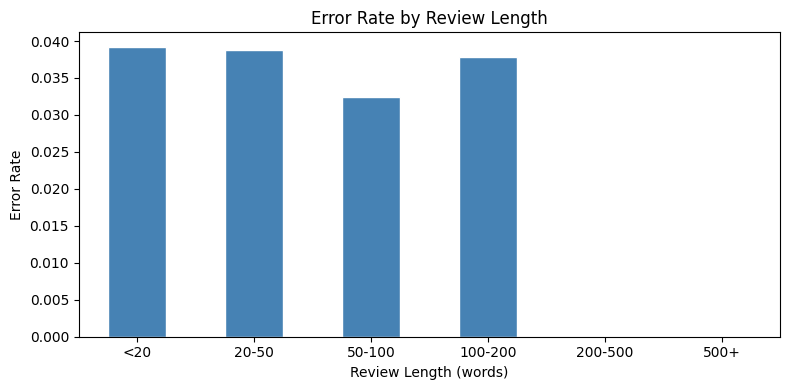

               count   sum  error_rate
length_bucket                         
<20              204   196    0.039216
20-50           1676  1611    0.038783
50-100          1852  1792    0.032397
100-200         1267  1219    0.037885
200-500            1     1    0.000000
500+               0     0         NaN


In [8]:
df["length_bucket"] = pd.cut(df["text_length"], bins=[0, 20, 50, 100, 200, 500, 10000],
                              labels=["<20", "20-50", "50-100", "100-200", "200-500", "500+"])
error_by_length = df.groupby("length_bucket")["correct"].agg(["count", "sum"])
error_by_length["error_rate"] = 1 - error_by_length["sum"] / error_by_length["count"]

fig, ax = plt.subplots(figsize=(8, 4))
error_by_length["error_rate"].plot(kind="bar", ax=ax, color="steelblue", edgecolor="white")
ax.set_xlabel("Review Length (words)")
ax.set_ylabel("Error Rate")
ax.set_title("Error Rate by Review Length")
ax.tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.show()

print(error_by_length)

### 4c. High-Confidence Errors (Most Interesting)
Cases where the model was very confident but wrong — these reveal systematic blind spots.

In [9]:
high_conf_errors = errors[errors["confidence"] > 0.95].sort_values("confidence", ascending=False)
print(f"High-confidence errors (>95%): {len(high_conf_errors)}\n")

for _, row in high_conf_errors.head(10).iterrows():
    true = "POS" if row["true_label"] == 1 else "NEG"
    pred = "POS" if row["pred_label"] == 1 else "NEG"
    print(f"[True: {true} | Pred: {pred} | Conf: {row['confidence']:.3f}]")
    print(f"Title: {row['title']}")
    print(f"Text:  {row['text'][:200]}")
    print("-" * 80)

High-confidence errors (>95%): 57

[True: POS | Pred: NEG | Conf: 1.000]
Title: Clock radio review
Text:  Display very dim. Sound (speakers not very good)Nice size for small space.Would not recommend.
--------------------------------------------------------------------------------
[True: POS | Pred: NEG | Conf: 0.999]
Title: Vitriolic Entertainment
Text:  Like the talk show, this book is entertaining in an over-the-top way. Savage has some good points, but his message is mostly lost in his fixation on blaming the mythic "LEFT" for all of our problems. 
--------------------------------------------------------------------------------
[True: NEG | Pred: POS | Conf: 0.999]
Title: Up to usual standards!
Text:  The standards being excellent! This is a warm, witty, and charming example of mystery writing. Quill is no hard boil 40's type and neither are is three favorite companions, even if this one leaves the
--------------------------------------------------------------------------------
[Tr

### 4d. Low-Confidence Correct Predictions
Cases where the model was uncertain but got it right — boundary examples.

In [10]:
low_conf_correct = df[df["correct"]].sort_values("confidence").head(10)

for _, row in low_conf_correct.iterrows():
    label = "POS" if row["true_label"] == 1 else "NEG"
    print(f"[Label: {label} | Conf: {row['confidence']:.3f}]")
    print(f"Text: {row['text'][:200]}")
    print("-" * 80)

[Label: POS | Conf: 0.500]
Text: Im just gonna give my ratings1.As You Sleep - 5/10---annoying, weak---least favorite song on the album2. Space - 7/10--decent, kinda repetetive--blends in3. Down - 9/10---very good song. Catchy, while
--------------------------------------------------------------------------------
[Label: POS | Conf: 0.507]
Text: i think with the totally hits cds they should add the young artists like hilary duff and jojo they are singers to you know
--------------------------------------------------------------------------------
[Label: NEG | Conf: 0.508]
Text: The tray is beautiful and just what I wanted, but there is a slight edge around the inside of the tray which causes anything that hits the edge to topple to the floor, especially wine glasses, Tabasco
--------------------------------------------------------------------------------
[Label: POS | Conf: 0.508]
Text: Lil Zane jumped in and off the charts faster than a speeding bullet. This album isn't bad if you lik

## 5. Summary

Key findings from the error analysis:
- The model achieves **97%+ F1** with most errors concentrated in low-confidence predictions
- High-confidence errors often involve **sarcasm**, **mixed sentiment**, or **very short reviews**
- Error rate tends to be higher for **very short reviews** (<20 words) with less context
- False Negatives and False Positives are roughly balanced, indicating no systematic class bias